<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# Smart-Turn — eval & compare runs

Held-out evaluation step. Score every `02_<letter>_*` checkpoint on
the test split in one pass and lay the numbers side by side. Each run
uses **its own** `threshold.json` (the operating point picked on
validation), so the F1 column reflects what each variant would
actually ship.

This notebook is the eval — no ONNX, no quantization. Pick a winner
from the table + PR overlay below, then run `04_export.ipynb` once
with `RUN_NAME` set to the winner to produce the shippable INT8 artifact.

## Configure

List every `RUN_NAME` you want compared. Each must already have a checkpoint at `checkpoints/<dataset>/<run>/` (run the corresponding `02_<letter>_*.ipynb` first).

In [18]:
from pathlib import Path

DATASET_NAME = "smart-turn-zh-0503"
RUN_NAMES = ["baseline", "specaugment"]

EXPORT_DIR = Path(f"../../datasets/{DATASET_NAME}").resolve()
CHECKPOINTS_ROOT = Path(f"../../checkpoints/{DATASET_NAME}").resolve()

TARGET_SR = 16_000
CHUNK_LENGTH = 8

assert EXPORT_DIR.exists(), f"{EXPORT_DIR.name} not found"
missing = [r for r in RUN_NAMES if not (CHECKPOINTS_ROOT / r).exists()]
assert not missing, (
    f"missing checkpoints for: {missing}. Run the corresponding "
    f"02_<letter>_*.ipynb to generate them."
)

print("dataset      :", DATASET_NAME)
print("runs         :", ", ".join(RUN_NAMES))
print("checkpoints  :", CHECKPOINTS_ROOT.relative_to(CHECKPOINTS_ROOT.parent.parent))
print("✅ config ready")

dataset      : smart-turn-zh-0503
runs         : baseline, specaugment
checkpoints  : checkpoints/smart-turn-zh-0503
✅ config ready


## Load test split

Only `ds["test"]` is needed here — comparison happens on the held-out
split.

In [19]:
from datasets import load_dataset, Audio, disable_progress_bars

disable_progress_bars()

test_path = EXPORT_DIR / "test.parquet"
assert test_path.exists(), "test.parquet missing — re-run the export with a non-zero test ratio."

ds = load_dataset("parquet", data_files={"test": str(test_path)})
ds = ds.cast_column("audio", Audio(sampling_rate=TARGET_SR))
print(f"test: {len(ds['test']):,}")
print("✅ dataset loaded")

test: 254
✅ dataset loaded


## Score every run

`score_run` (in `smart_turn.py`) loads a checkpoint + its
`threshold.json`, runs inference on the test split, and returns probs
+ labels + metrics. We loop over `RUN_NAMES` so each variant is
evaluated against the **same** test set with **its own** shipped
threshold.

In [20]:
from smart_turn import pick_device, score_run

device = pick_device()
print("device:", device)

# Display names are prefixed with `wavekat-` so any chart/table we share
# externally is clearly attributed. Checkpoint dirs on disk stay
# unprefixed (`baseline/`, `specaugment/`) — those names are picked by
# the corresponding 02_<letter>_*.ipynb.
DISPLAY_PREFIX = "wavekat-"

results = {}
for run_name in RUN_NAMES:
    ckpt = CHECKPOINTS_ROOT / run_name
    print(f"  scoring {run_name} ...")
    results[f"{DISPLAY_PREFIX}{run_name}"] = score_run(
        ckpt, ds["test"], TARGET_SR, CHUNK_LENGTH, device,
    )
print("✅ all runs scored")

device: mps
  scoring baseline ...


Loading weights:   0%|          | 0/80 [00:00<?, ?it/s]

  scoring specaugment ...


Loading weights:   0%|          | 0/80 [00:00<?, ?it/s]

✅ all runs scored


## Score pipecat baseline

Pull `pipecat-ai/smart-turn-v3` (whisper-tiny encoder + linear head — same architecture as ours, trained on a much larger multilingual corpus) and score it on **our** test set with their default threshold of 0.5. This is the reference any fine-tuned run has to beat to justify shipping our own model instead of theirs. Set `INCLUDE_PIPECAT = False` to skip the download.

In [21]:
from huggingface_hub import hf_hub_download
from smart_turn import score_onnx

INCLUDE_PIPECAT = True
PIPECAT_REPO = "pipecat-ai/smart-turn-v3"
PIPECAT_FILE = "smart-turn-v3.2-cpu.onnx"  # shipping artifact (INT8 quant)
PIPECAT_FE = "openai/whisper-tiny"          # their preprocessing source

if INCLUDE_PIPECAT:
    onnx_path = hf_hub_download(repo_id=PIPECAT_REPO, filename=PIPECAT_FILE)
    print(f"  scoring pipecat-v3 ({PIPECAT_FILE}) ...")
    results["pipecat-v3"] = score_onnx(
        onnx_path, PIPECAT_FE, ds["test"],
        TARGET_SR, CHUNK_LENGTH, threshold=0.5,
    )
    print("✅ pipecat scored")
else:
    print("⏭  pipecat skipped")

  scoring pipecat-v3 (smart-turn-v3.2-cpu.onnx) ...
✅ pipecat scored


## Metrics table

Held-out test metrics at each run's shipped threshold. **AP** (average
precision = area under PR curve) is threshold-independent — use it to
compare model quality without worrying about calibration.

In [22]:
cols = ["threshold", "accuracy", "precision", "recall", "f1", "average_precision"]
name_w = max(len("run"), max(len(r) for r in results))
header = f"{'run':<{name_w}}  " + "  ".join(f"{c:>10}" for c in cols)
print(header)
print("-" * len(header))
for run_name, r in results.items():
    row = f"{run_name:<{name_w}}  " + "  ".join(f"{r[c]:>10.4f}" for c in cols)
    print(row)

best_f1 = max(results, key=lambda n: results[n]["f1"])
best_ap = max(results, key=lambda n: results[n]["average_precision"])
print()
print(f"best test F1 : {best_f1}  ({results[best_f1]['f1']:.4f})")
print(f"best test AP : {best_ap}  ({results[best_ap]['average_precision']:.4f})")
print("✅ table printed")

run                   threshold    accuracy   precision      recall          f1  average_precision
--------------------------------------------------------------------------------------------------
wavekat-baseline         0.0800      0.8071      0.7586      0.8871      0.8178      0.9219
wavekat-specaugment      0.6200      0.8425      0.8281      0.8548      0.8413      0.9080
pipecat-v3               0.5000      0.7441      0.6980      0.8387      0.7619      0.8098

best test F1 : wavekat-specaugment  (0.8413)
best test AP : wavekat-baseline  (0.9219)
✅ table printed


## PR curves overlaid

One curve per run. The dot on each curve is that run's shipped
threshold (where it would actually operate). A curve that bows
further out toward (1, 1) is a better model regardless of where the
threshold lands; if two curves cross, you're in a precision/recall
trade and the right choice depends on the application.

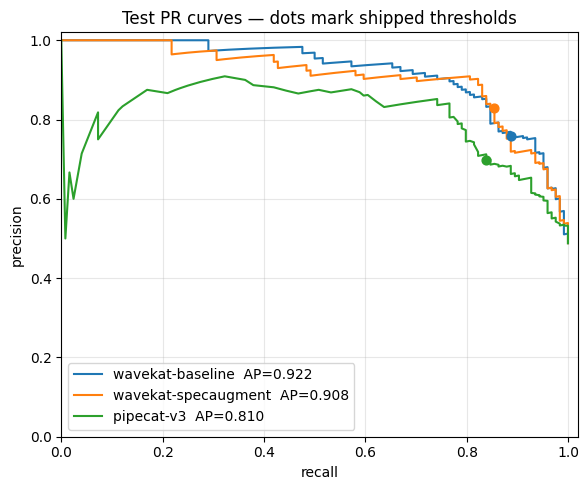

✅ PR curves drawn


In [23]:
# 0503
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(6, 5))
for run_name, r in results.items():
    p, recall, _ = precision_recall_curve(r["labels"], r["probs"])
    ax.plot(recall, p, label=f"{run_name}  AP={r['average_precision']:.3f}")
    ax.scatter([r["recall"]], [r["precision"]], s=40, zorder=5)

ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Test PR curves — dots mark shipped thresholds")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()
print("✅ PR curves drawn")

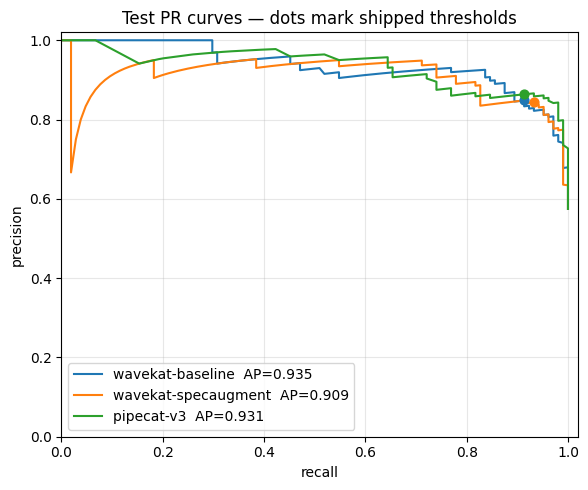

✅ PR curves drawn


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(6, 5))
for run_name, r in results.items():
    p, recall, _ = precision_recall_curve(r["labels"], r["probs"])
    ax.plot(recall, p, label=f"{run_name}  AP={r['average_precision']:.3f}")
    ax.scatter([r["recall"]], [r["precision"]], s=40, zorder=5)

ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Test PR curves — dots mark shipped thresholds")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()
print("✅ PR curves drawn")

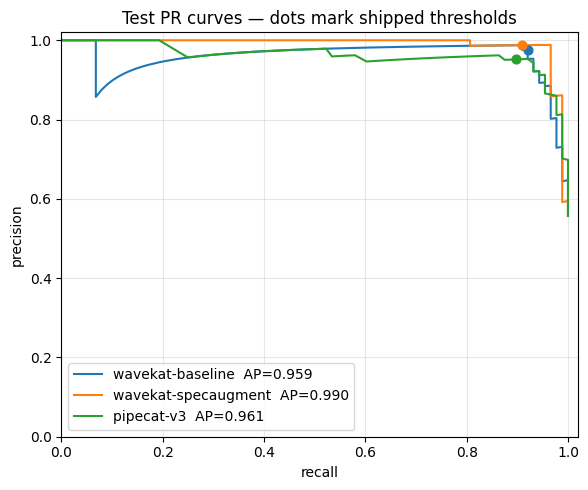

✅ PR curves drawn


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(6, 5))
for run_name, r in results.items():
    p, recall, _ = precision_recall_curve(r["labels"], r["probs"])
    ax.plot(recall, p, label=f"{run_name}  AP={r['average_precision']:.3f}")
    ax.scatter([r["recall"]], [r["precision"]], s=40, zorder=5)

ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Test PR curves — dots mark shipped thresholds")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()
print("✅ PR curves drawn")

## Next

Pick the winner from the table + PR plot above, then:

1. Open `04_export.ipynb`, set `RUN_NAME` to the winner, Run All.
2. That produces the FP32 + INT8 ONNX artifacts plus the latency benchmark.
3. Paste the chosen run's test F1 + INT8 drift into the experiments table in `README.md` so future runs have a baseline to beat.